# **Double the resolution**

In [1]:
import scanpy as sc
import anndata
import pandas as pd
import SM2ST as SM2ST
import STMGraph_pyG1
# import SMLED_pyG1 as SMLED
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.stats import pearsonr
os.environ['R_HOME'] = '/home/llx/software/miniconda3/envs/pyg_ms/lib/R'

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  **1 Read MSI**

In [2]:
# df_ms=pd.read_csv('/home/llx/project/jupyternotebook/1_pyg_backup/Data/MSD/mouse_brain_pen_dhb_50um_pixel_intensities.csv', skiprows=2,index_col=0)
# df_ms=pd.read_csv('/home/llx/project/MSI_data/mouse_pen_50um/mouse_pen_50um.csv',index_col=0)
df_ms=pd.read_csv('/home/llx/project/MSI_data/mouse_ito_30um/ito_30um_mad.csv',index_col=0)
df_ms

,x121_y1,x122_y1,x123_y1,x124_y1,x120_y2,x121_y2,x122_y2,x123_y2,x124_y2,x125_y2,...,x19_y180,x20_y180,x21_y180,x22_y180,x23_y180,x24_y180,x25_y180,x12_y181,x13_y181,x14_y181
152.020966,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
152.055574,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
154.024702,168.884988,173.589709,178.140641,0.000000,174.022542,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,141.996522,0.00000,152.399847
155.032674,914.838941,841.292449,685.393545,677.771875,864.347548,605.742957,471.56691,575.327534,615.13367,478.488232,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,474.338544,443.96218,673.394671
156.039791,175.582464,0.000000,0.000000,0.000000,173.381969,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002.575657,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
1003.580487,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
1006.491884,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
1020.533017,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000


## **2 create anndata**

In [3]:
def create_anndata_or(dataframe=None,pixel_size=1):
    
    df_ms_new=dataframe.iloc[:,:].T
    rows_all_zero = (df_ms_new == 0).all(axis=1)

    df_ms_new = df_ms_new[~rows_all_zero]
    df_ms_new = df_ms_new.apply(lambda x: x - x.min(), axis=0)
    rows = []
    cols = []
    for name in df_ms_new.index:
        x, y = name.split('_y')
        rows.append(int(x[1:]))
        cols.append(int(y))

    coordinates_df = pd.DataFrame({'array_row': rows, 'array_col': cols})
    coordinates_df.index = df_ms_new.index
    coordinates_physical_df = coordinates_df*pixel_size
    index_df = pd.DataFrame(index=dataframe.index)
    adata = anndata.AnnData(X=df_ms_new.values, obs=coordinates_df, var=index_df)#4
    adata.obsm['spatial'] = coordinates_physical_df.values
    return adata

In [4]:
adata = create_anndata_or(dataframe=df_ms,pixel_size=30)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

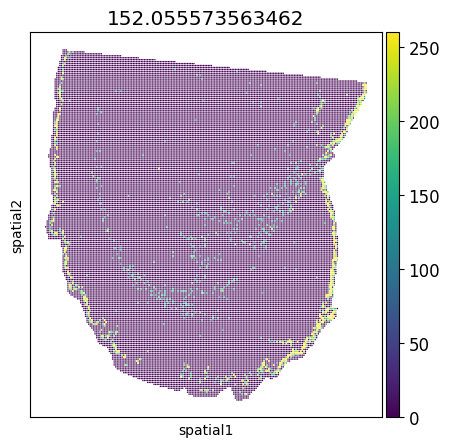

In [7]:
plot_gene = '152.055573563462'
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

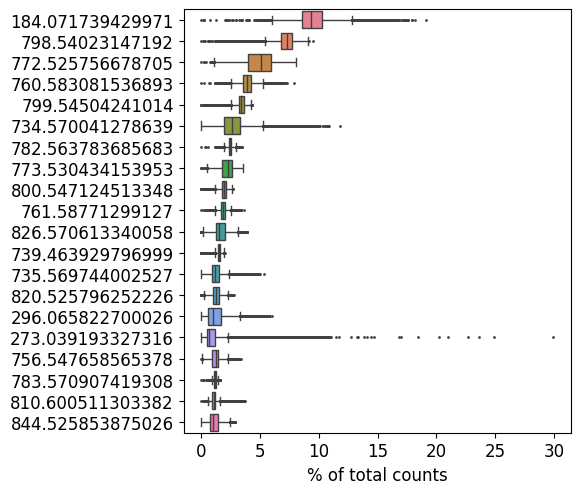

In [8]:
sc.pl.highest_expr_genes(adata, n_top=20)

## **3 super resolution**

### **3.1 Interpolation**

In [9]:
def anndata_transfer_resolution2(adata=None,pixel_size=1):
    original_coordinates = adata.obsm['spatial'].copy()
    new_coordinates_1 = adata.obsm['spatial'].copy()
    new_coordinates_1[:,1] =  new_coordinates_1[:,1] + pixel_size//2
    new_adata_1=adata.copy()
    # Divide the matrix by pixel_size//2
    divided_new_coordinates_1 = new_coordinates_1 // (pixel_size//2)
    # Create a DataFrame with column names set as 'array_row' and 'array_col'
    df_divided_new_coordinates_1 = pd.DataFrame(divided_new_coordinates_1, columns=['array_row', 'array_col'])
    new_adata_1.obs = df_divided_new_coordinates_1
    new_adata_1.obsm['spatial'] = new_coordinates_1
    adata_combined_1 = sc.concat([adata, new_adata_1], axis=0, join='outer', uns_merge='unique')
    
    new_coordinates_2 = adata_combined_1.obsm['spatial'].copy()
    new_coordinates_2 = new_coordinates_2.copy()
    new_coordinates_2[:,0] =  new_coordinates_2[:,0] + pixel_size//2
    new_adata_2=adata_combined_1.copy()
    # Divide the matrix by pixel_size//2
    divided_new_coordinates_2 = new_coordinates_2 // (pixel_size//2)
    # Create a DataFrame with column names set as 'array_row' and 'array_col'
    df_divided_new_coordinates_2 = pd.DataFrame(divided_new_coordinates_2, columns=['array_row', 'array_col'])
    new_adata_2.obs = df_divided_new_coordinates_2
    new_adata_2.obsm['spatial'] = new_coordinates_2
    adata_combined_2 = sc.concat([adata_combined_1, new_adata_2], axis=0, join='outer', uns_merge='unique')
    # Reset the index of the .obs DataFrame and start it from 0.
    adata_combined_2.obs = adata_combined_2.obs.reset_index(drop=True)
    adata_combined_2.obs_names = adata_combined_2.obs_names.astype(str)
    return adata_combined_2

In [10]:
new_adata = anndata_transfer_resolution2(adata=adata,pixel_size=30)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [11]:
new_adata.obsm['spatial']

array([[3630,   30],
       [3660,   30],
       [3690,   30],
       ...,
       [ 375, 5445],
       [ 405, 5445],
       [ 435, 5445]])

<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

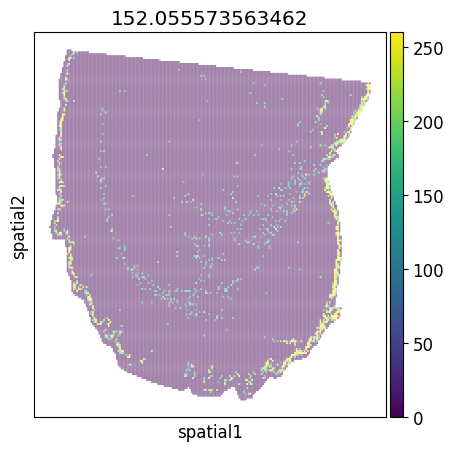

In [14]:
plot_gene = '152.055573563462'
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(new_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [15]:
sc.pp.normalize_total(new_adata, target_sum=1e4)
sc.pp.log1p(new_adata)

<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

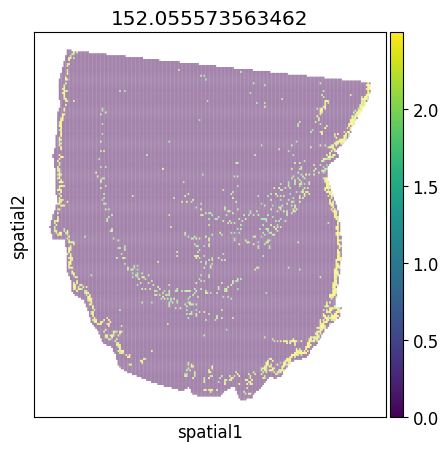

In [16]:
plot_gene = '152.055573563462'
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(new_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

### **3.2 STMGraph Correction**

In [17]:
import random
import torch.backends.cudnn as cudnn
import torch
# torch.set_default_dtype(torch.float64)
def fix_seed(seed):
    #seed = 2023
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    cudnn.deterministic = True
    cudnn.benchmark = False
    # torch.use_deterministic_algorithms(True)  # 强制报错非确定性操作
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  
seed = 52
fix_seed(seed)

In [19]:
# grid setting
num_batch_x = 3
num_batch_y = 2
new_adata.obs['x'] = new_adata.obsm['spatial'][:,0]
new_adata.obs['y'] = new_adata.obsm['spatial'][:,1]

In [20]:
import seaborn as sns
def Batch_Data(adata, num_batch_x, num_batch_y, spatial_key=['X', 'Y'], plot_Stats=False):
    Sp_df = adata.obs.loc[:, spatial_key].copy()
    Sp_df = np.array(Sp_df)
    batch_x_coor_1 = [np.percentile(Sp_df[:, 0], (1/num_batch_x)*x*100) for x in range(num_batch_x+1)]
    batch_y_coor_1 = [np.percentile(Sp_df[:, 1], (1/num_batch_y)*x*100) for x in range(num_batch_y+1)]
    batch_x_coor_2 = [np.percentile(Sp_df[:, 0], (1/(num_batch_x*2))*x*100) for x in range(1,num_batch_x*2+1,2)]
    batch_y_coor_2 = [np.percentile(Sp_df[:, 1], (1/(num_batch_y*2))*x*100) for x in range(1,num_batch_y*2+1,2)]
    
    Batch_list = []
    for it_x in range(num_batch_x):
        for it_y in range(num_batch_y):
            min_x_1 = batch_x_coor_1[it_x]
            max_x_1 = batch_x_coor_1[it_x+1]
            min_y_1 = batch_y_coor_1[it_y]
            max_y_1 = batch_y_coor_1[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_1 <= x <= max_x_1)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_1 <= y <= max_y_1)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x-1):
        for it_y in range(num_batch_y-1):
            min_x_2 = batch_x_coor_2[it_x]
            max_x_2 = batch_x_coor_2[it_x+1]
            min_y_2 = batch_y_coor_2[it_y]
            max_y_2 = batch_y_coor_2[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_2 <= x <= max_x_2)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_2 <= y <= max_y_2)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x-1):
        for it_y in range(num_batch_y):
            min_x_2 = batch_x_coor_2[it_x]
            max_x_2 = batch_x_coor_2[it_x+1]
            min_y_1 = batch_y_coor_1[it_y]
            max_y_1 = batch_y_coor_1[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_2 <= x <= max_x_2)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_1 <= y <= max_y_1)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x):
        for it_y in range(num_batch_y-1):
            min_x_1 = batch_x_coor_1[it_x]
            max_x_1 = batch_x_coor_1[it_x+1]
            min_y_2 = batch_y_coor_2[it_y]
            max_y_2 = batch_y_coor_2[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_1 <= x <= max_x_1)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_2 <= y <= max_y_2)]
            Batch_list.append(temp_adata)
    if plot_Stats:
        f, ax = plt.subplots(figsize=(1, 3))
        plot_df = pd.DataFrame([x.shape[0] for x in Batch_list], columns=['#spot/batch'])
        sns.boxplot(y='#spot/batch', data=plot_df, ax=ax)
        sns.stripplot(y='#spot/batch', data=plot_df, ax=ax, color='red', size=5)
    return Batch_list

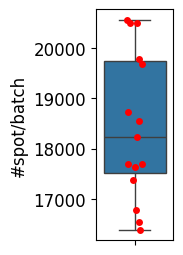

In [21]:
Batch_list_1 = Batch_Data(new_adata, num_batch_x=num_batch_x, num_batch_y=num_batch_y,spatial_key=['x', 'y'], plot_Stats=True)

In [22]:
# Consturcting network for each batch
for temp_adata in Batch_list_1:
    STMGraph_pyG1.Cal_Spatial_Net(temp_adata, model='KNN', k_cutoff=8, delta_err=0.05)
    #STAGATE_pyG.Stats_Spatial_Net(temp_adata)

------Calculating spatial graph...
The graph contains 129306 edges, 16389 cells.
7.8898 neighbors per cell on average.


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


------Calculating spatial graph...
The graph contains 162700 edges, 20562 cells.
7.9127 neighbors per cell on average.
------Calculating spatial graph...


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 162110 edges, 20498 cells.
7.9086 neighbors per cell on average.
------Calculating spatial graph...


...

/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 137436 edges, 17380 cells.
7.9077 neighbors per cell on average.
------Calculating spatial graph...


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 146516 edges, 18542 cells.
7.9018 neighbors per cell on average.


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


In [23]:
STMGraph_pyG1.Cal_Spatial_Net(new_adata, model='KNN', k_cutoff=8, delta_err=0.05)
adata_om1 = STMGraph_pyG1.Transfer_pytorch_Data(new_adata)

------Calculating spatial graph...
The graph contains 876748 edges, 110164 cells.
7.9586 neighbors per cell on average.


In [24]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
data_list1 = [STMGraph_pyG1.Transfer_pytorch_Data(temp_adata) for temp_adata in Batch_list_1]
for temp in data_list1:
    temp.to(device)

In [25]:
from torch_geometric.loader import DataLoader
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

num_epoch = 600
delayed_ema_epoch = 130 # 110
lr=0.0001
weight_decay=1e-4
hidden_dims = [512, 30]
alpha = 1
mask_ratio = 0.5
noise = 0.0
# gradient_clipping = 5.

def sce_loss(x, y, alpha=1.0):
    x = F.normalize(x, p=2, dim=-1)
    y = F.normalize(y, p=2, dim=-1)
    loss = (1 - (x * y).sum(dim=-1)).pow_(alpha)
    loss = loss.mean()
    return loss
# batch_size=1 or 2
loader = DataLoader(data_list1, batch_size=1, shuffle=True,num_workers = 0)
model = STMGraph_pyG1.STMGraph(hidden_dims = [data_list1[0].x.shape[1]]+hidden_dims,delayed_ema_epoch=delayed_ema_epoch, momentum=0.996).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

total_steps = num_epoch * len(loader)
pbar = tqdm(total=total_steps, desc='Training')

for epoch in range(1, num_epoch + 1):
    for batch in loader:
        model.train()
        optimizer.zero_grad()

        z, z_ema, out1, out2, mask_nodes, keep_nodes, ATT = model(
            epoch, batch.x, batch.edge_index,
            mask_rate=mask_ratio, replace_rate=noise
        )

        loss1 = sce_loss(batch.x[mask_nodes], out1[mask_nodes], alpha=alpha) \
              + sce_loss(batch.x[mask_nodes], out2[mask_nodes], alpha=alpha)
        loss2 = F.mse_loss(z[keep_nodes], z_ema[keep_nodes])
        loss = loss1 + loss2

        loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)#  gradient_clipping
        optimizer.step()

        # 只保留 epoch 和 loss
        pbar.set_postfix({'epoch': epoch, 'loss': f'{loss.item():.4f}'})
        pbar.update(1)
pbar.close()

Training: 100%|█████| 9000/9000 [10:52<00:00, 13.79it/s, epoch=600, loss=0.0524]


In [26]:
# The total network
device_cpu = torch.device('cpu')
adata_om1.to(device_cpu)
model.to(device_cpu)

STMGraph(
  (encoding_mask_noise): encoding_mask_noise()
  (random_remask): random_remask()
  (conv1): GATv2Conv(1389, 512, heads=1)
  (conv2): GATv2Conv(512, 30, heads=1)
  (conv3): GATv2Conv(30, 512, heads=1)
  (conv4): GATv2Conv(512, 1389, heads=1)
  (conv1_ema): GATv2Conv(1389, 512, heads=1)
  (conv2_ema): GATv2Conv(512, 30, heads=1)
)

In [27]:
model.eval()
z, z_ema, out_1, out_2, mask_nodes, keep_nodes,ATT = model(epoch, adata_om1.x, adata_om1.edge_index, mask_rate=0, replace_rate=0)
STMGraph_rep = z.to('cpu').detach().numpy()
new_adata.obsm['STMGraph'] = STMGraph_rep

In [28]:
ReX = out_1.to('cpu').detach().numpy()
ReX[ReX<0] = 0
new_adata.layers['STMGraph_ReX'] = ReX

In [29]:
# # 假设 adata_om1.edge_index 和 ATT 已经在 CPU 上
# edge_index = adata_om1.edge_index.cpu()  # [2, E]               
# att = ATT.detach().squeeze().cpu() # [E]

# # 构造 MultiIndex：每行是一个 (src, dst) 对
# index = pd.MultiIndex.from_arrays(
#     [edge_index[0].numpy(), edge_index[1].numpy()],
#     names=['src', 'dst']
# )

# # 构造 Series，再 unstack 成 DataFrame
# att_series = pd.Series(att.numpy(), index=index)
# att_df = att_series.unstack(fill_value=0.0)   # 没有的边填 0.0，也可填 NaN
# att_df = att_df.values
# for it in range(att_df.shape[0]):
#     att_df[it, it] = 0

In [30]:
# import networkx as nx
# G_atten = nx.from_numpy_array(att_df)
# M = G_atten.number_of_edges()
# edge_colors = range(2, M + 2)

In [31]:
# coor_df = pd.DataFrame(new_adata.obsm['spatial'].copy(), index=new_adata.obs_names)
# coor_df[1] = -1 * coor_df[1]
# image_pos = dict(zip(range(coor_df.shape[0]), [np.array(coor_df.iloc[it,]) for it in range(coor_df.shape[0])]))

In [32]:
# labels = nx.get_edge_attributes(G_atten,'weight')

In [33]:
# import matplotlib as mpl
# fig, ax = plt.subplots(figsize=[100,100])
# nx.draw_networkx_nodes(G_atten, image_pos, node_size=5, ax=ax)
# cmap = plt.cm.plasma
# edges = nx.draw_networkx_edges(G_atten, image_pos, edge_color=list(labels.values()),width=4, ax=ax,
#                                edge_cmap=cmap,edge_vmax=0.25,edge_vmin=0.05)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin = 0.05, vmax=0.25))
# # sm._A = []
# # plt.colorbar(sm)
# # ax.set_axis_off()
# sm.set_array([])
# # fig.colorbar(sm, ax=ax)   # 关键：明确指定 ax
# cbar = fig.colorbar(sm, ax=ax)          # 返回 Colorbar 对象
# cbar.ax.tick_params(labelsize=100, length=40, width=5)       # 刻度数字大小
# ax.set_axis_off()
# plt.show()

In [34]:
# ReX = out.to('cpu').detach().numpy()
# ReX[ReX<0] = 0
# new_adata.layers['SMGLED_ReX'] = ReX

<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

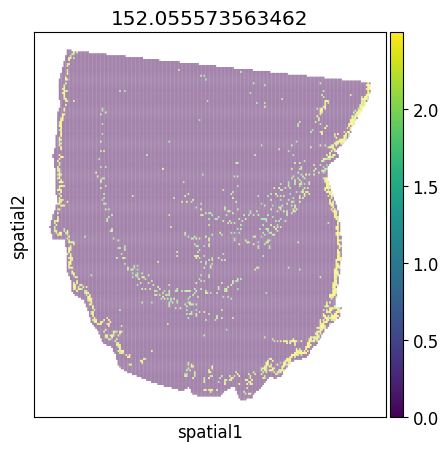

In [35]:
plot_gene = '152.055573563462'
fig, ax = plt.subplots(figsize=(5, 5)) 
plt.rcParams['font.size'] = 12 
sc.pl.embedding(new_adata, basis="spatial",color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

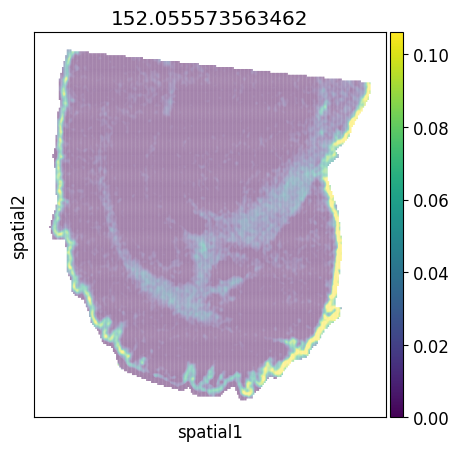

In [36]:
plot_gene = '152.055573563462'
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12 
sc.pl.embedding(new_adata, basis="spatial", layer = 'STMGraph_ReX',color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '716.453819448202'}, xlabel='spatial1', ylabel='spatial2'>

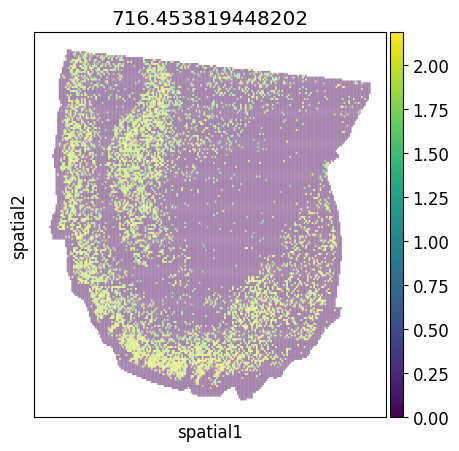

In [37]:
plot_gene = '716.453819448202'
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(new_adata, basis="spatial",color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '716.453819448202'}, xlabel='spatial1', ylabel='spatial2'>

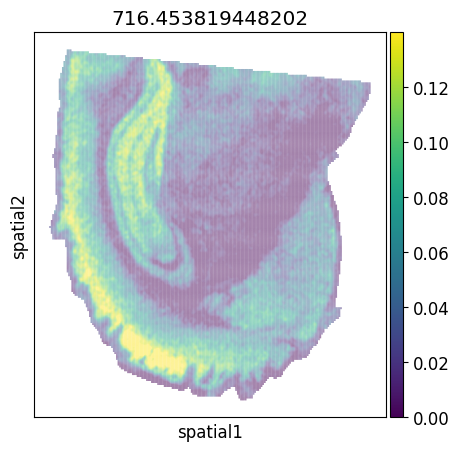

In [38]:
plot_gene = '716.453819448202'
fig, ax = plt.subplots(figsize=(5, 5)) 
plt.rcParams['font.size'] = 12
sc.pl.embedding(new_adata, basis="spatial", layer = 'STMGraph_ReX',color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '870.541344137682'}, xlabel='spatial1', ylabel='spatial2'>

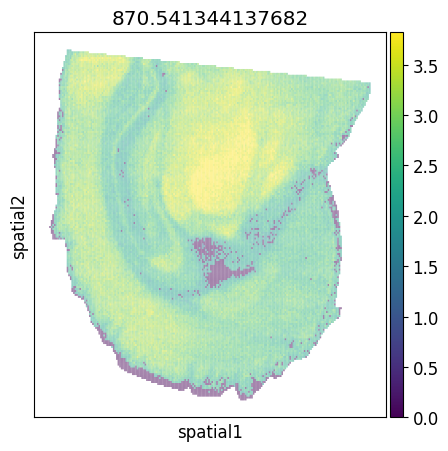

In [39]:
#new
plot_gene = '870.541344137682'
fig, ax = plt.subplots(figsize=(5, 5)) 
plt.rcParams['font.size'] = 12
sc.pl.embedding(new_adata, basis="spatial",color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '870.541344137682'}, xlabel='spatial1', ylabel='spatial2'>

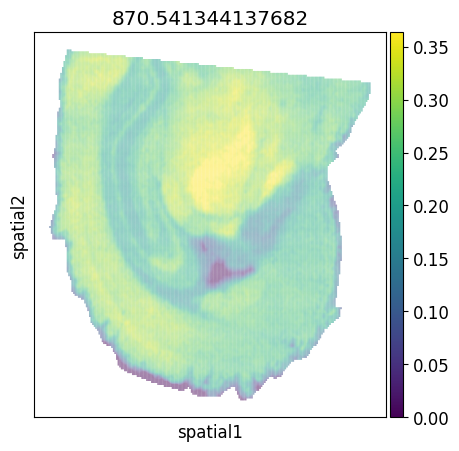

In [40]:
#new
plot_gene = '870.541344137682'
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(new_adata, basis="spatial", layer = 'STMGraph_ReX',color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '837.668742291891'}, xlabel='spatial1', ylabel='spatial2'>

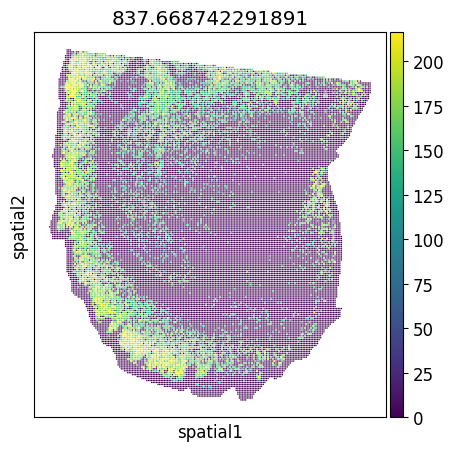

In [41]:
plot_gene = '837.668742291891'
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(adata, basis="spatial",color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '837.668742291891'}, xlabel='spatial1', ylabel='spatial2'>

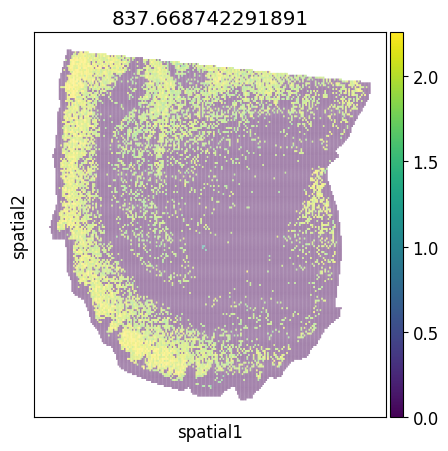

In [42]:
plot_gene = '837.668742291891'
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(new_adata, basis="spatial",color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '837.668742291891'}, xlabel='spatial1', ylabel='spatial2'>

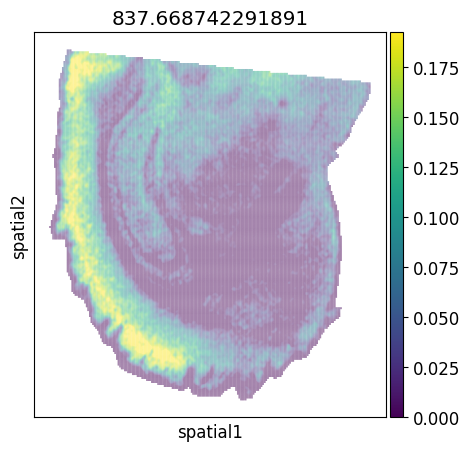

In [43]:
plot_gene = '837.668742291891'
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12 
sc.pl.embedding(new_adata, basis="spatial", layer = 'STMGraph_ReX',color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '874.496450812922'}, xlabel='spatial1', ylabel='spatial2'>

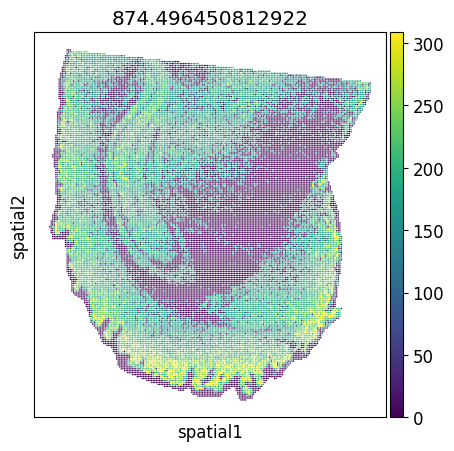

In [44]:
plot_gene = '874.496450812922'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial",color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '874.496450812922'}, xlabel='spatial1', ylabel='spatial2'>

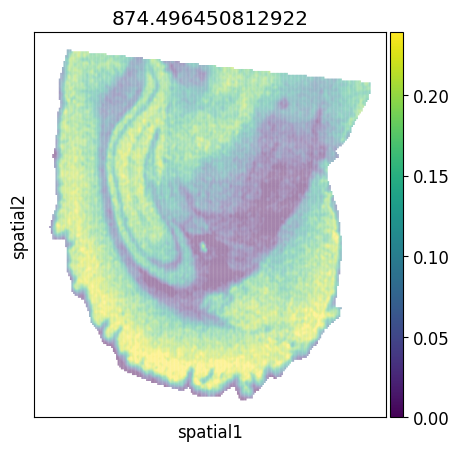

In [45]:
plot_gene = '874.496450812922'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(new_adata, basis="spatial", layer = 'STMGraph_ReX',color=plot_gene, show=False,vmax='p99',ax=ax)

In [46]:
new_adata

AnnData object with n_obs × n_vars = 110164 × 1389
    obs: 'array_row', 'array_col', 'x', 'y'
    uns: 'log1p', 'Spatial_Net'
    obsm: 'spatial', 'STMGraph'
    layers: 'STMGraph_ReX'

## **4 SRMGraph Cluster**

In [47]:
adata_REX = anndata_transfer_resolution2(adata=adata,pixel_size=30)
adata_REX.X=new_adata.layers['STMGraph_ReX']

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [48]:
import squidpy as sq
sq.gr.spatial_neighbors(adata_REX)
sq.gr.spatial_autocorr(adata_REX, mode="moran", genes=adata_REX.var_names)
sq.gr.spatial_autocorr(adata_REX, mode="geary", genes=adata_REX.var_names)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 8 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 8 variables were constant, will return nan for these.
  warnings.warn(


In [49]:
adata_SMLED_high_moran_genes = adata_REX.uns['moranI']['I'][(adata_REX.uns['moranI']['I'] > 0.5) & (adata_REX.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_moran = adata_REX[:, adata_SMLED_high_moran_genes]

adata_SMLED_high_geary_genes = adata_REX.uns['gearyC']['C'][(adata_REX.uns['gearyC']['C'] < 0.5) & (adata_REX.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_geary = adata_REX[:, adata_SMLED_high_geary_genes]

In [50]:
adata_SMLED_set1 = set(adata_SMLED_high_geary.var_names)
adata_SMLED_set2 = set(adata_SMLED_high_moran.var_names)
adata_SMLED_v = adata_SMLED_set1&adata_SMLED_set2

In [51]:
import squidpy as sq
sq.gr.spatial_neighbors(adata)
sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)
sq.gr.spatial_autocorr(adata, mode="geary", genes=adata.var_names)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 221 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 221 variables were constant, will return nan for these.
  warnings.warn(


In [52]:
adata_high_moran_genes = adata.uns['moranI']['I'][(adata.uns['moranI']['I'] > 0.5) & (adata.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
adata_high_moran = adata[:, adata_high_moran_genes]

adata_high_geary_genes = adata.uns['gearyC']['C'][(adata.uns['gearyC']['C'] < 0.5) & (adata.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
adata_high_geary = adata[:, adata_high_geary_genes]

In [53]:
ms_adata_set1 = set(adata_high_geary.var_names)
ms_adata_set2 = set(adata_high_moran.var_names)
ms_adata_v = ms_adata_set1&ms_adata_set2

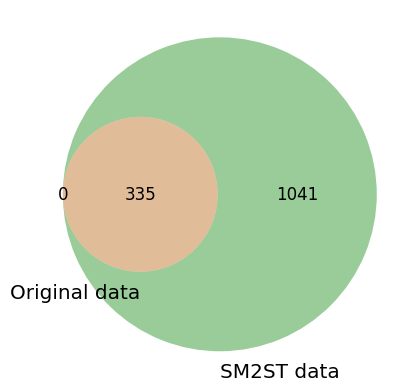

In [54]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

set1 = ms_adata_v
set2 = adata_SMLED_v

venn = venn2([set1, set2], ('Original data', 'SM2ST data'))

venn.get_label_by_id('100').set_text(f'{len(set1 - set2)}')
venn.get_label_by_id('010').set_text(f'{len(set2 - set1)}')
venn.get_label_by_id('110').set_text(f'{len(set1 & set2)}')

plt.show()

In [56]:
# new_adata.write_h5ad('/public/home/stu_wanghaoyu/project/1_pyg/Data/MSD/adata_pen_masked_fill2.h5ad')
# new_adata = sc.read_h5ad('/public/home/stu_wanghaoyu/project/1_pyg/Data/MSD/adata_pen_masked_fill2.h5ad')

In [57]:
# adata_REX = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_ito_30um_mad_rex.h5ad')

In [58]:
adata_REX

AnnData object with n_obs × n_vars = 110164 × 1389
    obs: 'array_row', 'array_col'
    uns: 'spatial_neighbors', 'moranI', 'gearyC'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [59]:
adata_REX_h = adata_REX.copy()  # Create a copy
# sc.pp.highly_variable_genes(adata_REX_h, flavor="seurat_v3", n_top_genes=300)
# sc.pp.normalize_total(adata_REX_h, target_sum=1e4)
# sc.pp.log1p(adata_REX_h)
# adata_REX_h = adata_REX_h[:, adata_REX_h.var['highly_variable']]

In [61]:
# grid setting
num_batch_x = 3
num_batch_y = 2
adata_REX_h = adata_REX_h.copy()  # 将视图转换为副本
adata_REX_h.obs['x'] = adata_REX_h.obsm['spatial'][:,0]
adata_REX_h.obs['y'] = adata_REX_h.obsm['spatial'][:,1]

In [62]:
adata_REX_h.obs

,array_row,array_col,x,y
0,121,1,3630,30
1,122,1,3660,30
2,123,1,3690,30
3,124,1,3720,30
4,120,2,3600,60
...,...,...,...,...
110159,49,361,735,5415
110160,51,361,765,5415
110161,25,363,375,5445
110162,27,363,405,5445


In [63]:
import seaborn as sns
def Batch_Data(adata, num_batch_x, num_batch_y, spatial_key=['X', 'Y'], plot_Stats=False):
    Sp_df = adata.obs.loc[:, spatial_key].copy()
    Sp_df = np.array(Sp_df)
    batch_x_coor_1 = [np.percentile(Sp_df[:, 0], (1/num_batch_x)*x*100) for x in range(num_batch_x+1)]
    batch_y_coor_1 = [np.percentile(Sp_df[:, 1], (1/num_batch_y)*x*100) for x in range(num_batch_y+1)]
    batch_x_coor_2 = [np.percentile(Sp_df[:, 0], (1/(num_batch_x*2))*x*100) for x in range(1,num_batch_x*2+1,2)]
    batch_y_coor_2 = [np.percentile(Sp_df[:, 1], (1/(num_batch_y*2))*x*100) for x in range(1,num_batch_y*2+1,2)]
    
    Batch_list = []
    for it_x in range(num_batch_x):
        for it_y in range(num_batch_y):
            min_x_1 = batch_x_coor_1[it_x]
            max_x_1 = batch_x_coor_1[it_x+1]
            min_y_1 = batch_y_coor_1[it_y]
            max_y_1 = batch_y_coor_1[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_1 <= x <= max_x_1)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_1 <= y <= max_y_1)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x-1):
        for it_y in range(num_batch_y-1):
            min_x_2 = batch_x_coor_2[it_x]
            max_x_2 = batch_x_coor_2[it_x+1]
            min_y_2 = batch_y_coor_2[it_y]
            max_y_2 = batch_y_coor_2[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_2 <= x <= max_x_2)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_2 <= y <= max_y_2)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x-1):
        for it_y in range(num_batch_y):
            min_x_2 = batch_x_coor_2[it_x]
            max_x_2 = batch_x_coor_2[it_x+1]
            min_y_1 = batch_y_coor_1[it_y]
            max_y_1 = batch_y_coor_1[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_2 <= x <= max_x_2)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_1 <= y <= max_y_1)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x):
        for it_y in range(num_batch_y-1):
            min_x_1 = batch_x_coor_1[it_x]
            max_x_1 = batch_x_coor_1[it_x+1]
            min_y_2 = batch_y_coor_2[it_y]
            max_y_2 = batch_y_coor_2[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_1 <= x <= max_x_1)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_2 <= y <= max_y_2)]
            Batch_list.append(temp_adata)
    if plot_Stats:
        f, ax = plt.subplots(figsize=(1, 3))
        plot_df = pd.DataFrame([x.shape[0] for x in Batch_list], columns=['#spot/batch'])
        sns.boxplot(y='#spot/batch', data=plot_df, ax=ax)
        sns.stripplot(y='#spot/batch', data=plot_df, ax=ax, color='red', size=5)
    return Batch_list

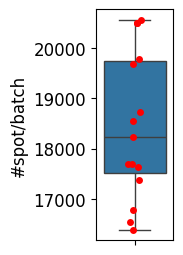

In [64]:
Batch_list_2 = Batch_Data(adata_REX_h, num_batch_x=num_batch_x, num_batch_y=num_batch_y,spatial_key=['x', 'y'], plot_Stats=True)

In [65]:
# Consturcting network for each batch
for temp_adata in Batch_list_2:
    STMGraph_pyG1.Cal_Spatial_Net(temp_adata, model='KNN', k_cutoff=8, delta_err=0.05)
    #STAGATE_pyG.Stats_Spatial_Net(temp_adata)

------Calculating spatial graph...
The graph contains 129306 edges, 16389 cells.
7.8898 neighbors per cell on average.
------Calculating spatial graph...


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 162700 edges, 20562 cells.
7.9127 neighbors per cell on average.
------Calculating spatial graph...


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 162110 edges, 20498 cells.
7.9086 neighbors per cell on average.
------Calculating spatial graph...


...

/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 137436 edges, 17380 cells.
7.9077 neighbors per cell on average.
------Calculating spatial graph...


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 146516 edges, 18542 cells.
7.9018 neighbors per cell on average.


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


In [66]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
data_list2 = [STMGraph_pyG1.Transfer_pytorch_Data(temp_adata) for temp_adata in Batch_list_2]
for temp in data_list2:
    temp.to(device)

In [67]:
STMGraph_pyG1.Cal_Spatial_Net(adata_REX_h, model='KNN', k_cutoff=8, delta_err=0.05)
adata_om2 = STMGraph_pyG1.Transfer_pytorch_Data(adata_REX_h)

------Calculating spatial graph...
The graph contains 876748 edges, 110164 cells.
7.9586 neighbors per cell on average.


In [68]:
from torch_geometric.loader import DataLoader

import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

def sce_loss(x, y, alpha=1.0):
    x = F.normalize(x, p=2, dim=-1)
    y = F.normalize(y, p=2, dim=-1)
    loss = (1 - (x * y).sum(dim=-1)).pow_(alpha)

    loss = loss.mean()
    return loss
seed=52
fix_seed(seed)
# batch_size=1 or 2
loader = DataLoader(data_list2, batch_size=1, shuffle=True,num_workers = 0)
model = STMGraph_pyG1.STMGraph(hidden_dims = [data_list2[0].x.shape[1]]+hidden_dims, delayed_ema_epoch=delayed_ema_epoch, momentum=0.99).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

total_steps = num_epoch * len(loader)
pbar = tqdm(total=total_steps, desc='Training')

for epoch in range(1, num_epoch + 1):
    for batch in loader:
        model.train()
        optimizer.zero_grad()

        z, z_ema, out1, out2, mask_nodes, keep_nodes, ATT = model(
            epoch, batch.x, batch.edge_index,
            mask_rate=mask_ratio, replace_rate=noise
        )

        loss1 = sce_loss(batch.x[mask_nodes], out1[mask_nodes], alpha=alpha) \
              + sce_loss(batch.x[mask_nodes], out2[mask_nodes], alpha=alpha)
        loss2 = F.mse_loss(z[keep_nodes], z_ema[keep_nodes])
        loss = loss1 + loss2

        loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)#  gradient_clipping
        optimizer.step()

        # 只保留 epoch 和 loss
        pbar.set_postfix({'epoch': epoch, 'loss': f'{loss.item():.4f}'})
        pbar.update(1)
pbar.close()

Training: 100%|█████| 9000/9000 [11:03<00:00, 13.57it/s, epoch=600, loss=0.0036]


In [69]:
# The total network
device_cpu = torch.device('cpu')
adata_om2.to(device_cpu)
model.to(device_cpu)

STMGraph(
  (encoding_mask_noise): encoding_mask_noise()
  (random_remask): random_remask()
  (conv1): GATv2Conv(1389, 512, heads=1)
  (conv2): GATv2Conv(512, 30, heads=1)
  (conv3): GATv2Conv(30, 512, heads=1)
  (conv4): GATv2Conv(512, 1389, heads=1)
  (conv1_ema): GATv2Conv(1389, 512, heads=1)
  (conv2_ema): GATv2Conv(512, 30, heads=1)
)

In [70]:
model.eval()
z, z_ema, out_1, out_2, mask_nodes, keep_nodes,ATT = model(epoch,adata_om2.x, adata_om2.edge_index, mask_rate=0, replace_rate=0)
STMGraph_rep = z.to('cpu').detach().numpy()
adata_REX_h.obsm['STMGraph'] = STMGraph_rep

In [71]:
# ReX = out_2.to('cpu').detach().numpy()
# ReX[ReX<0] = 0
# adata_REX.layers['STMGraph_ReX'] = ReX

In [72]:
adata_REX_h = STMGraph_pyG1.mclust_R(adata_REX_h, used_obsm='STMGraph', num_cluster=15)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'STMGraph'}, xlabel='spatial1', ylabel='spatial2'>

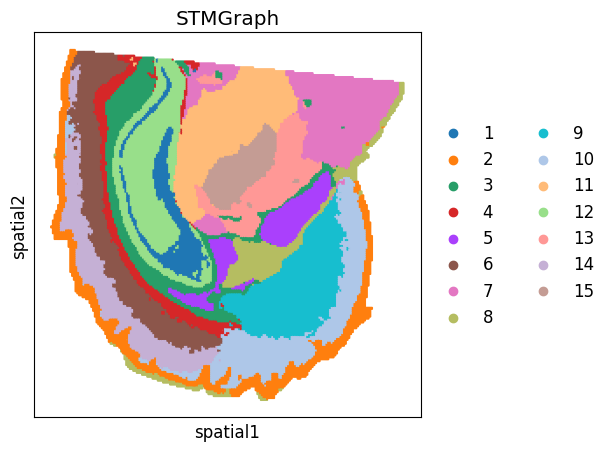

In [73]:
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
sc.pl.embedding(adata_REX_h, basis="spatial", color="mclust",s=10, show=False, title='STMGraph', ax=ax)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


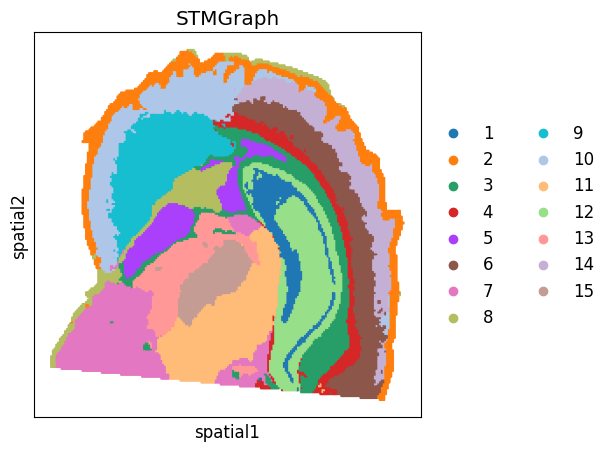

In [74]:
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.embedding(adata_REX_h, basis="spatial", color="mclust", s=10, show=False, title='STMGraph', ax=ax)
ax.invert_xaxis()  # 反转 x 轴
ax.invert_yaxis()  # 反转 y 轴

In [75]:
# adata_REX.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_ito_30um_mad_rex.h5ad')
# adata_REX = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_ito_30um_mad_rex.h5ad')

In [108]:
adata_REX_h.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_ito_30um_mad_rex_h.h5ad')

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

def icc_anova(x, group):
    """
    The single-factor ANOVA method is used to calculate ICC(1,1) (unconditional, single assessor)
    x: 1-D expression vector
    group: cluster label, of the same length as x 
    """
    group = pd.Categorical(group)
    k = len(group.categories)          # Cluster Number
    n_i = group.value_counts().values  # Number of Samples in Each Cluster
    n0 = n_i.mean()                    # Average Cluster Size

    # Quick ANOVA
    grand_mean = x.mean()
    ss_total = ((x - grand_mean)**2).sum()

    ss_between = 0
    for g, idx in enumerate(group.categories):
        mask = group == idx
        ss_between += mask.sum() * (x[mask].mean() - grand_mean)**2
    ss_within = ss_total - ss_between

    df_between = k - 1
    df_within = x.size - k
    ms_between = ss_between / df_between
    ms_within  = ss_within  / df_within

    if ms_between <= ms_within:       
        return 0.0
    icc = (ms_between - ms_within) / (ms_between + (n0 - 1)*ms_within)
    return max(0.0, icc)

def cluster_icc(adata, cluster_key='louvain'):
    """Calculate the cluster-level ICC for each gene of adata"""
    icc_list = []
    genes = adata.var_names
    clusters = adata.obs[cluster_key]
    for g in genes:
        icc_list.append(icc_anova(adata[:, g].X.toarray().ravel()
                                  if hasattr(adata.X, 'toarray')
                                  else adata[:, g].X.ravel(),
                                  clusters))
    adata.var['icc'] = icc_list
    return adata

In [ ]:
cluster_icc(adata_REX_h, cluster_key='mclust')

high_icc = adata_REX_h.var.sort_values('icc', ascending=False)
print(high_icc[['icc']])

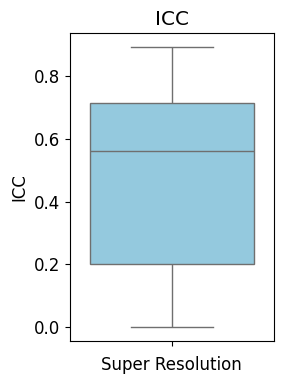

In [107]:
# 1. Remove genes with an ICC value of 0 (or NaN)
keep = adata_REX_h.var['icc'] > 0
adata_filt = adata_REX_h[:, keep].copy()
print(f"保留基因数：{adata_filt.n_vars}")
icc_df = adata_filt.var[['icc']].reset_index(drop=True)

plt.figure(figsize=(3, 4))
sns.boxplot(data=icc_df, y='icc', color='skyblue')
plt.title('ICC')
plt.ylabel('ICC')
plt.xlabel('Super Resolution')
plt.tight_layout()
plt.show()